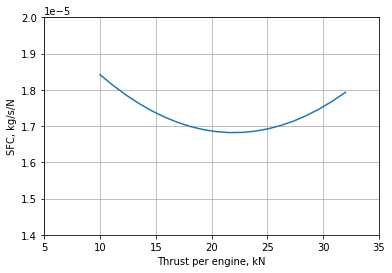

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.constants import foot

from fastoad.base.flight_point import FlightPoint
from fastoad.constants import EngineSetting
from fastoad.models.propulsion.fuel_propulsion.rubber_engine import RubberEngine

engine = RubberEngine(
    bypass_ratio=4.9,
    overall_pressure_ratio=32.6,
    turbine_inlet_temperature=1600,
    mto_thrust=117880,
    maximum_mach=0.85,
    design_altitude=10058.4,
    delta_t4_climb=-50.0,
    delta_t4_cruise=-100.0,
)

thrust = np.linspace(10.0e3, 32.0e3, 20)

bucket_points = pd.DataFrame(
    FlightPoint(
        altitude=35000 * foot,
        mach=0.78,
        thrust=np.linspace(10.0e3, 32.0e3, 20),
        thrust_rate=0.0,
        thrust_is_regulated=True,
        engine_setting=EngineSetting.convert("CRUISE"),
    )
)

engine.compute_flight_points(bucket_points)
fig = plt.plot(bucket_points.thrust / 1.e3, bucket_points.sfc)
plt.xlim(5,35)
plt.ylim(1.4e-5,2.0e-5)
plt.xlabel("Thrust per engine, kN")
plt.ylabel("SFC, kg/s/N")

plt.grid()
plt.show()

<div class="row">
  <div class="column">
    <img src="./img/CeRAS_bucket_curve.jpg" width="500">
  </div>
</div>